# PageRank & HITS Algorithm

import

In [8]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os
import pickle

load , save

In [9]:
DATA_INPUT = "../data/processed_transactions/association_rules.csv" 

CHARTS_OUTPUT = "../visualizations/charts/"
NETWORKS_OUTPUT = "../visualizations/networks/"

os.makedirs(CHARTS_OUTPUT, exist_ok=True)
os.makedirs(NETWORKS_OUTPUT, exist_ok=True)

# Network (Graph)

In [ ]:
rules = pd.read_csv(DATA_INPUT)

In [13]:
G = nx.DiGraph()

top_rules = rules.sort_values(by='lift', ascending=False).head(50).copy()

for _, row in top_rules.iterrows():
    source = str(row['antecedents']).strip("frozenset({})' ")
    target = str(row['consequents']).strip("frozenset({})' ")
    G.add_edge(source, target, weight=row['lift'])

print(f" Graph Statistics:")
print(f"- Number of Products (Nodes): {G.number_of_nodes()}")
print(f"- Number of Associations (Edges): {G.number_of_edges()}")

 Graph Statistics:
- Number of Products (Nodes): 41
- Number of Associations (Edges): 50


# PageRank Algorithm

In [14]:
pagerank_scores = nx.pagerank(G, weight='weight', alpha=0.85)

pr_df = pd.DataFrame(list(pagerank_scores.items()), columns=['Product', 'PageRank'])
pr_df = pr_df.sort_values(by='PageRank', ascending=False)

print("Top 10 Influential Products (PageRank):")
display(pr_df.head(10))

Top 10 Influential Products (PageRank):


,Product,PageRank
1,SABRENT Rocket 32GB DDR4 SO-DIMM 3200MHz Memor...,0.040937
32,Echo Auto (1st gen) - Hands-free Alexa in your...,0.032144
11,NETGEAR Orbi Pro WiFi 6 Tri-Band Mesh System (...,0.031576
33,"Echo Show 8 (1st Gen, 2019 release) -- HD smar...",0.029157
36,"Amazon Fire HD 8 tablet, 8"" HD display, 64 GB,...",0.027834
19,"Lexar E-Series 128GB Micro SD Card 2 Pack, mic...",0.026112
5,ROOFULL External CD DVD Drive USB 3.0 Type-C P...,0.024390
3,"""NexFoto 32GB Large 15 inch Digital Picture Fr...",0.024390
2,16 FT Inflatable Projector Movie Screen for Ou...,0.024390
38,JSAUX USB-C to USB A Cable 3.1A Fast Charging ...,0.024390


# HITS Algorithm (Hubs and Authorities)

In [15]:
hubs, authorities = nx.hits(G, max_iter=100)

hits_df = pd.DataFrame({
    'Product': list(hubs.keys()),
    'Hub_Score': list(hubs.values()),
    'Authority_Score': [authorities[node] for node in hubs.keys()]
})

hits_df = hits_df.sort_values(by='Authority_Score', ascending=False)
print(" Top Products by Authority Score:")
display(hits_df.head(10))

 Top Products by Authority Score:


,Product,Hub_Score,Authority_Score
1,SABRENT Rocket 32GB DDR4 SO-DIMM 3200MHz Memor...,2.980117e-01,2.980117e-01
0,"Lexar E-Series 128GB Micro SD Card 2 Pack, mic...",2.203449e-01,2.203449e-01
11,NETGEAR Orbi Pro WiFi 6 Tri-Band Mesh System (...,1.994279e-01,1.994279e-01
19,"Lexar E-Series 128GB Micro SD Card 2 Pack, mic...",1.471231e-01,1.471231e-01
10,"Lexar E-Series 128GB Micro SD Card 2 Pack, mic...",8.847222e-02,8.847222e-02
18,NETGEAR Orbi Pro WiFi 6 Tri-Band Mesh System (...,4.662016e-02,4.662016e-02
35,"Echo Show 5 (2nd Gen, 2021 release) | Smart di...",-1.687863e-18,7.822349e-17
31,"Amazon Fire HD 10 Tablet Case (7th Generation,...",-7.314062e-19,5.848004e-17
6,"DYMO LabelWriter 5XL Label Printer, Automatic ...",-2.648054e-17,5.666399e-17
37,"JSAUX Micro USB Cable Android Charger, (2-Pack...",-2.220872e-18,5.072885e-17


# Network Visualization

🕸️ Network diagram saved to: ../visualizations/networks/product_influence_network.png


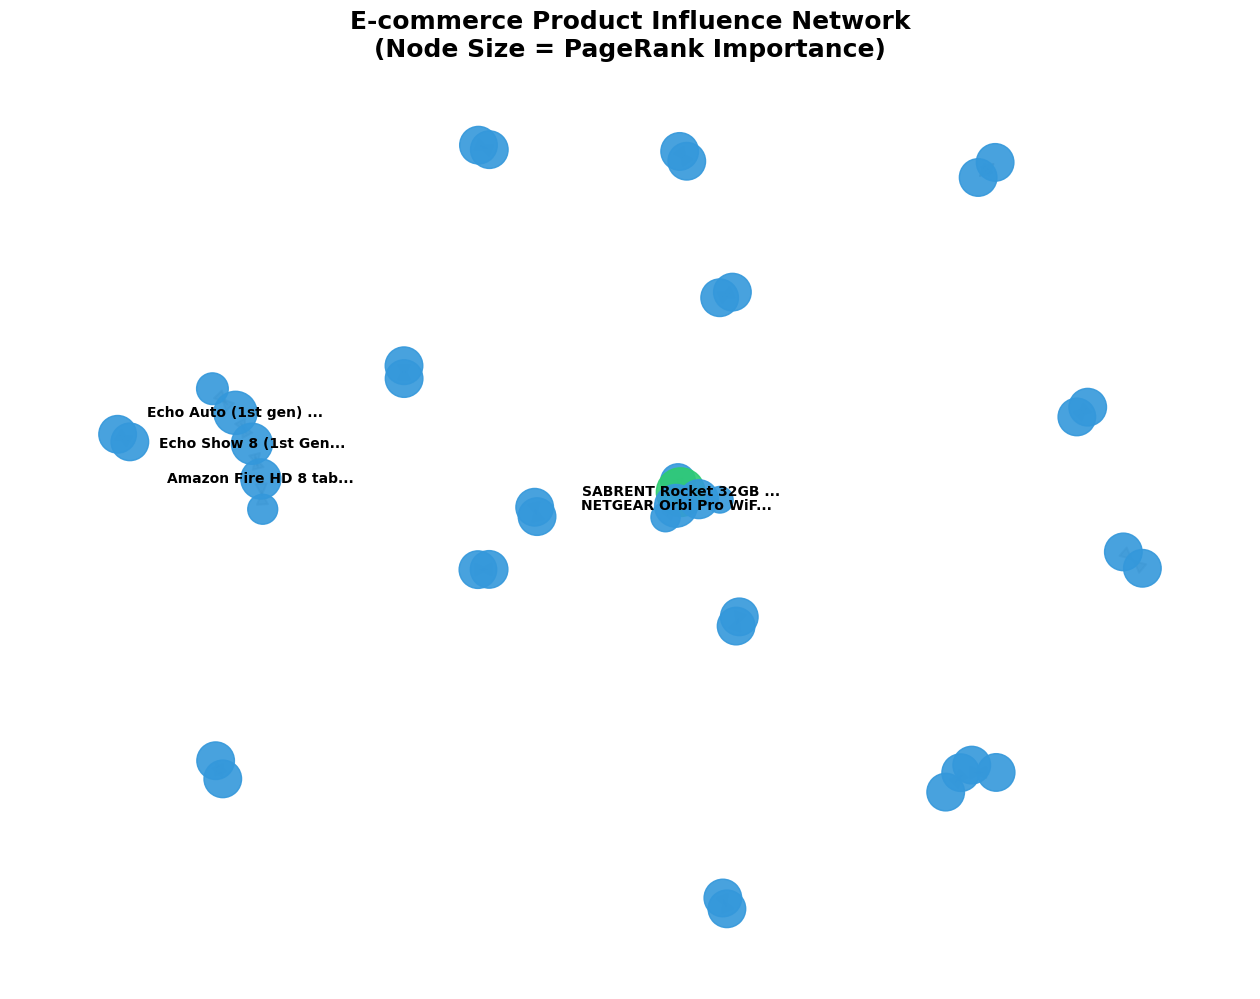

In [ ]:
plt.figure(figsize=(16, 12))

pos = nx.spring_layout(G, k=0.6, seed=42)

node_sizes = [pagerank_scores[node] * 30000 for node in G.nodes()]

max_pr_node = pr_df.iloc[0]['Product']
node_colors = ['#2ecc71' if node == max_pr_node else '#3498db' for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.4, edge_color='gray', arrowsize=20)

top_5_labels = pr_df.head(5)['Product'].values
labels = {node: node[:20] + "..." if node in top_5_labels else "" for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_weight='bold')

plt.title("E-commerce Product Influence Network\n(Node Size = PageRank Importance)", fontsize=18, fontweight='bold')
plt.axis('off')

net_plot_path = os.path.join(NETWORKS_OUTPUT, 'product_influence_network.png')
plt.savefig(net_plot_path, dpi=300, bbox_inches='tight')
print(f" Network diagram saved to: {net_plot_path}")

plt.show()

C:\Users\Matrix\AppData\Local\Temp\ipykernel_5172\1618142239.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\Matrix\AppData\Local\Temp\ipykernel_5172\1618142239.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels)


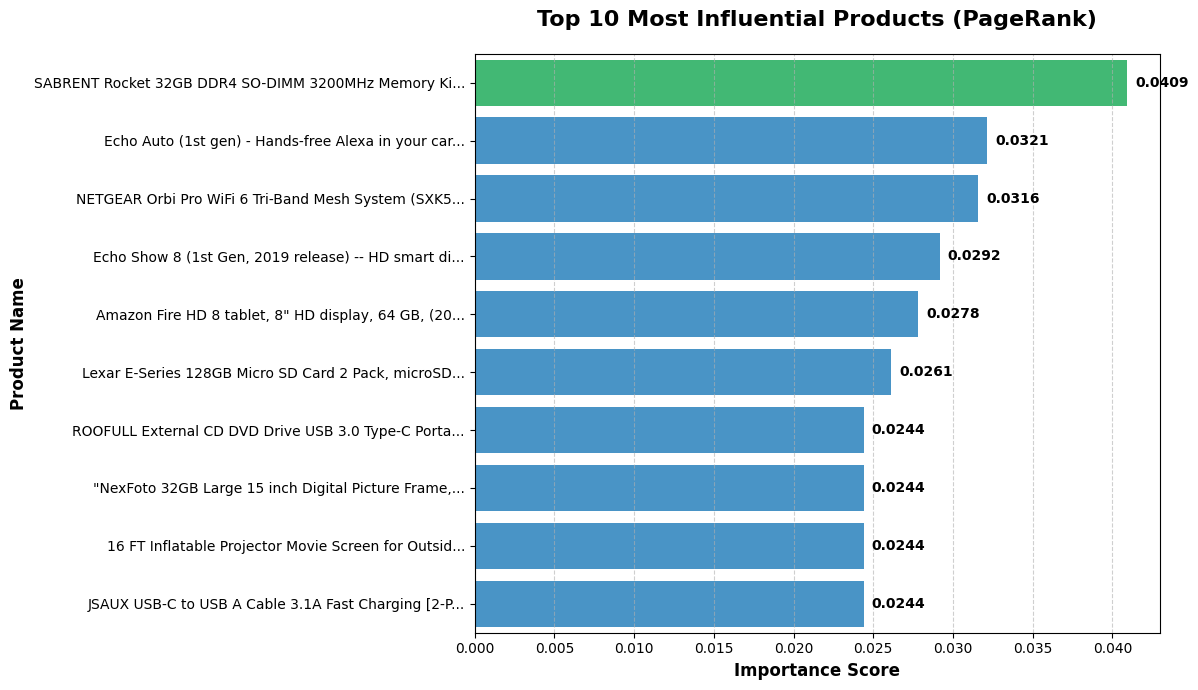

 Professional Bar Chart generated. Green represents the most influential product.


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

top_10_pr = pr_df.head(10).copy()
score_col = top_10_pr.columns[1]
product_col = top_10_pr.columns[0]
colors = ['#2ecc71'] + ['#3498db'] * 9
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x=score_col, 
    y=product_col, 
    data=top_10_pr, 
    palette=colors
)

for i, p in enumerate(ax.patches):
    width = p.get_width()
    ax.text(width + 0.0005, p.get_y() + p.get_height()/2, 
            f'{width:.4f}', va='center', fontsize=10, fontweight='bold')
new_labels = [label[:50] + '...' if len(label) > 50 else label for label in top_10_pr[product_col]]
ax.set_yticklabels(new_labels)
plt.title('Top 10 Most Influential Products (PageRank)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Product Name', fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("../visualizations/charts/final_pagerank_bar_chart.png", dpi=300)
plt.show()

print(f" Professional Bar Chart generated. Green represents the most influential product.")